<a href="https://colab.research.google.com/github/harshitmogre/ai-learning-assistant/blob/main/PrincipalComponentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
# 1. Load and Explore the Dataset

df=pd.read_csv('/content/PCA Dataset.csv');

# First five records
# print(df.head());

# Number of rows and columns
# print(df.shape);

# Column names
# print(df.columns);

# Basic statistical information
# print(df.describe());

# Identify the feature that should not be used for PCA and explain why.


In [22]:
from sklearn.preprocessing import StandardScaler
# 2. Select Features

feature=['Study_Hours','Attendance','Assignment_Score','Quiz_Score','Internal_Marks','Practical_Score','Midterm_Score','Previous_Sem_Marks','Final_Marks'];

data_for_pca=df[feature];

In [ ]:
# 3. Standardize the Data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_pca);
print(scaled_data);

scaled_data_df=pd.DataFrame(scaled_data,columns=feature);
print(scaled_data_df);

print("top 5 records");
print(scaled_data_df.head());

In [ ]:
# 4. Apply PCA

from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(scaled_data);

explained_variance = pca.explained_variance_ratio_

cumulative_variance = explained_variance.cumsum()

pca_results = pd.DataFrame({ "Principal Component": [ f"PC{i+1}" for i in range(len(explained_variance))],"Explained Variance Ratio": explained_variance,"Cumulative Explained Variance": cumulative_variance})

print(pca_results)

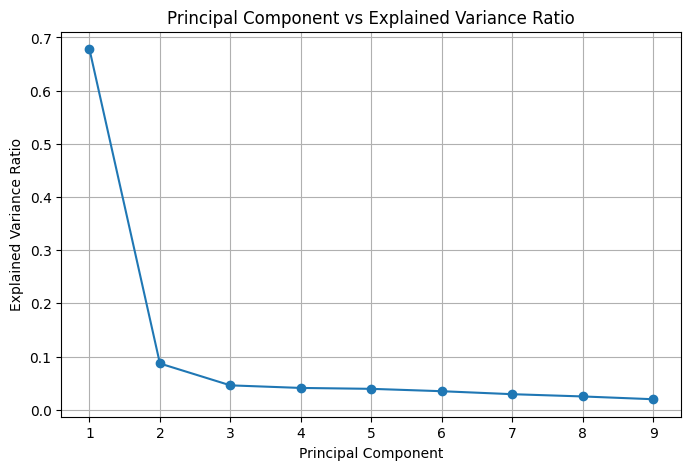

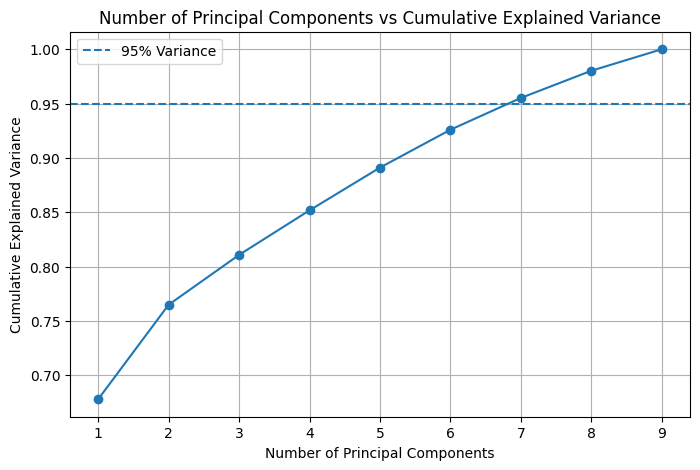

In [27]:
# 5. Visualize Explained Variance

plt.figure(figsize=(8, 5))

plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o");

plt.xlabel("Principal Component");
plt.ylabel("Explained Variance Ratio");
plt.title("Principal Component vs Explained Variance Ratio");

plt.xticks(range(1, len(explained_variance) + 1));

plt.grid(True);
plt.show();



plt.figure(figsize=(8, 5));

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o");

plt.axhline(y=0.95,linestyle="--",label="95% Variance");

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Number of Principal Components vs Cumulative Explained Variance")

plt.xticks(range(1, len(cumulative_variance) + 1))

plt.grid(True)
plt.legend()

plt.show()

In [29]:
# 6. Select Principal Components

import numpy as np

n_components = np.argmax( cumulative_variance >= 0.95 ) + 1;


variance_retained = cumulative_variance[n_components - 1];

print("Original number of features:", len(feature));
print("Required variance: 95%");
print("Number of selected components:", n_components);
print("Variance retained:", variance_retained * 100, "%");

Original number of features: 9
Required variance: 95%
Number of selected components: 7
Variance retained: 95.51968295589884 %


In [30]:
# 7. Transform the Dataset


pca_selected = PCA(n_components=n_components);


X_reduced = pca_selected.fit_transform(scaled_data);


pc_columns = [f"PC{i+1}" for i in range(n_components)];


X_reduced_df = pd.DataFrame( X_reduced, columns=pc_columns);


print("First 5 rows after PCA:");
print(X_reduced_df.head());


print("\nShape after PCA:");
print(X_reduced_df.shape);

print("\nOriginal Shape:");
print(X.shape);

print("\nReduced Shape:");
print(X_reduced_df.shape);

First 5 rows after PCA:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7
0  1.057121 -0.805409 -0.972406 -0.258505 -0.195045  0.818722  0.374884
1 -3.718962  0.377668  0.911122 -0.460000 -0.213983 -0.075225 -0.059487
2  2.128859 -1.367161  0.589456  0.529501 -0.072583  1.059027  0.433069
3  4.098350 -0.390211  0.279567 -0.976335 -0.127052 -0.909308  0.522084
4 -5.378573  0.088403 -0.245971 -0.501974 -0.295226 -0.371702 -0.650753

Shape after PCA:
(150, 7)

Original Shape:


NameError: name 'X' is not defined

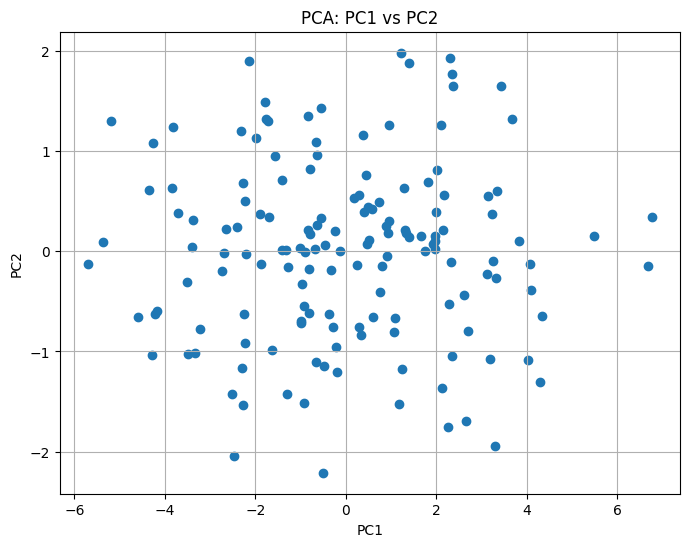

In [31]:
# 8. Visualize PCA Result

plt.figure(figsize=(8, 6))

plt.scatter(X_reduced_df["PC1"], X_reduced_df["PC2"])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2")

plt.grid(True)
plt.show()

In [ ]:
# 9. How many features were present before PCA?

X.shape

In [ ]:
# 10. How many principal components were required to retain 95% variance?

print(n_components);

In [ ]:
# 11. What percentage of variance is explained by PC1?

pc1_variance = explained_variance[0] * 100

print("Variance explained by PC1:", pc1_variance, "%")

In [ ]:
# 12. Which principal component explains maximum variance?

max_index = np.argmax(explained_variance)

print("Principal component with maximum variance:",f"PC{max_index + 1}");

In [35]:
# 13. How much dimensionality reduction was achieved?

original_features = X.shape[1]
reduced_features = X_reduced_df.shape[1]

reduction = original_features - reduced_features

reduction_percentage = (
    reduction / original_features
) * 100

print("Original features:", original_features)
print("Reduced features:", reduced_features)
print("Features removed:", reduction)
print("Dimensionality reduction:", reduction_percentage, "%")

NameError: name 'X' is not defined

In [ ]:
# 14. Was there information loss?

information_retained = variance_retained * 100
information_loss = 100 - information_retained

print("Variance retained:", information_retained, "%")
print("Variance not retained:", information_loss, "%")